# Visualization

In [10]:
import os

ds_pos_results = [
    "data\\ds_pos\\all-MiniLM-L6-v2\\tsne\\100",
    "data\\ds_pos\\all-MiniLM-L6-v2\\umap\\100",
    "data\\ds_pos\\all-mpnet-base-v2\\tsne\\100",
    "data\\ds_pos\\all-mpnet-base-v2\\umap\\100",
    "data\\ds_pos\\nomic-embed-text-v1.5\\tsne\\100",
    "data\\ds_pos\\nomic-embed-text-v1.5\\umap\\100",
]

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

for path in ds_pos_results:
    if not os.path.exists(path):
        print("[ ", path," ] not found. Skipping...")
        ds_pos_results.remove(path)

if len(ds_pos_results) < 1:
    raise Exception("No datasets were found.")

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_tsne_100_20251008T143805.pdf


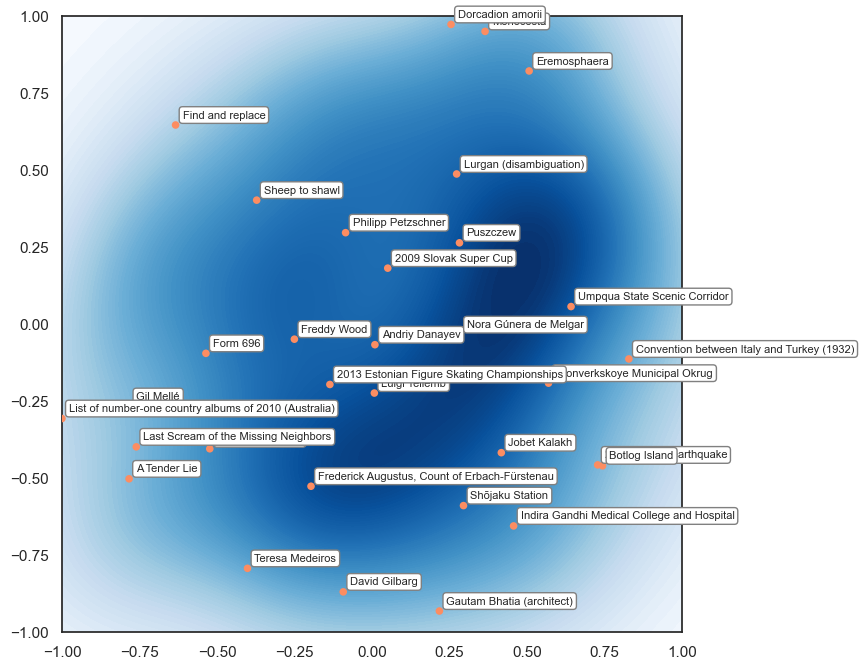

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_umap_100_20251008T143807.pdf


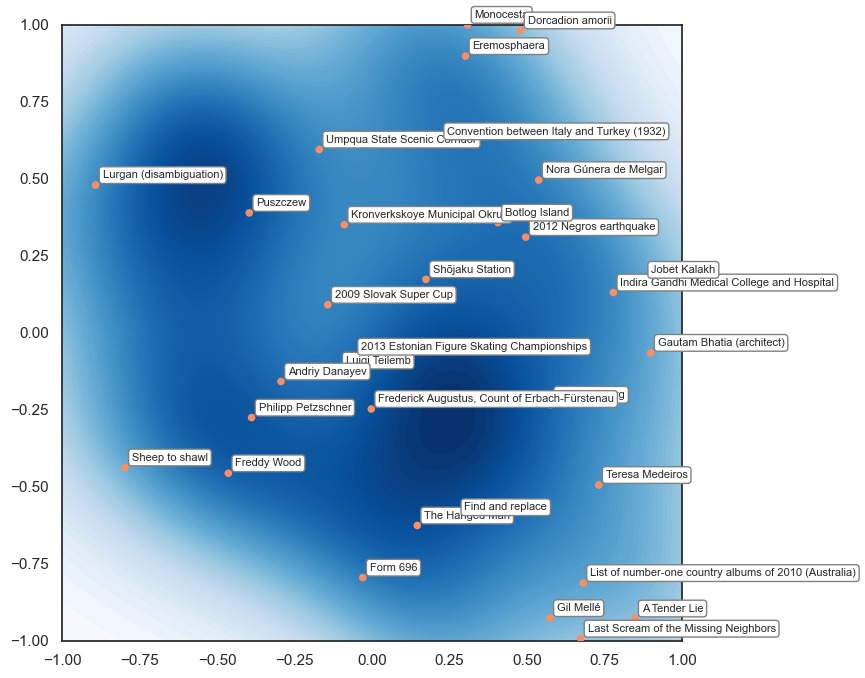

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_tsne_100_20251008T143807.pdf


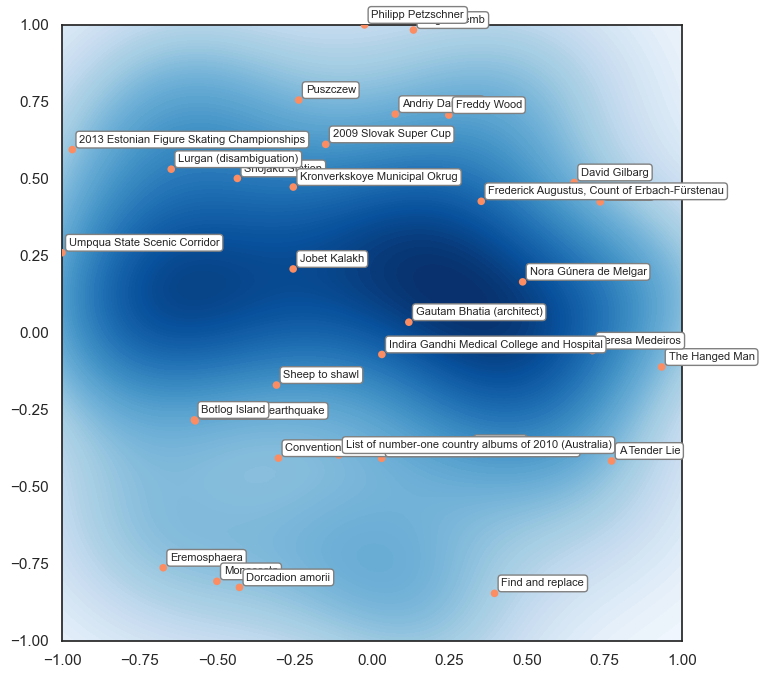

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_umap_100_20251008T143808.pdf


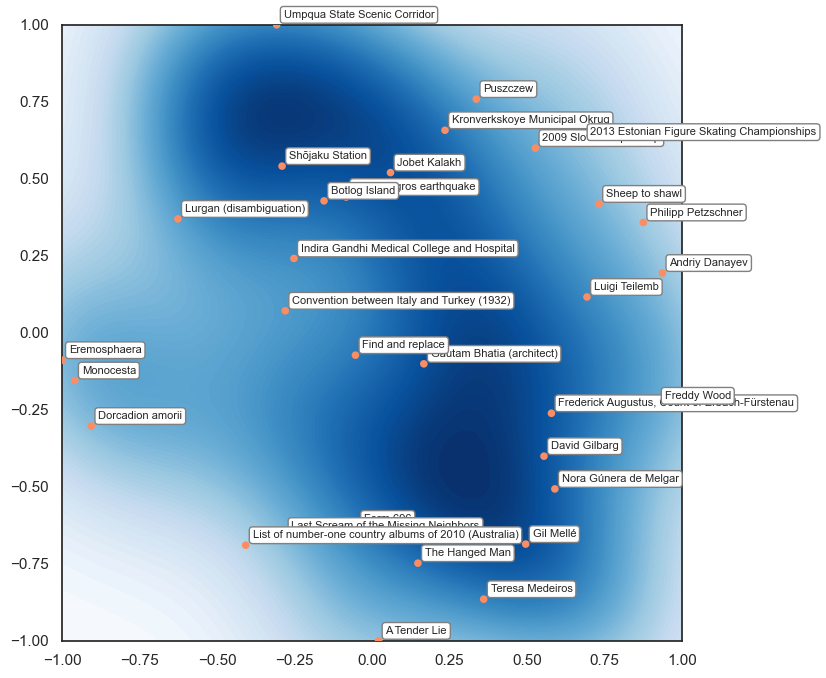

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_tsne_100_20251008T143809.pdf


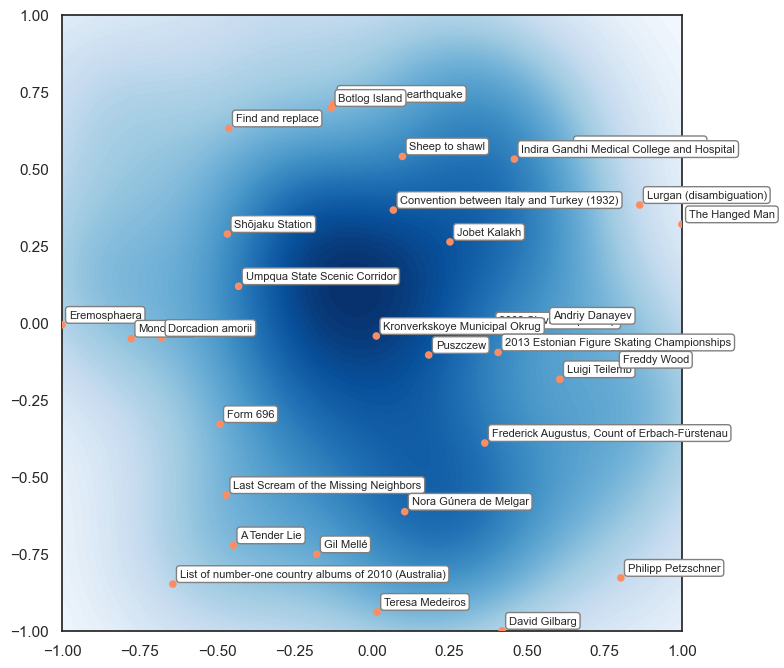

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_umap_100_20251008T143810.pdf


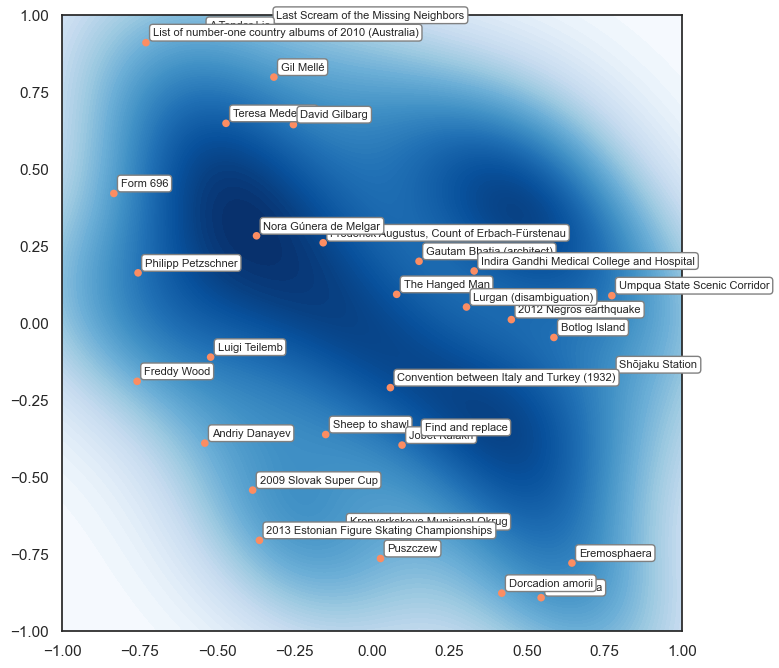

In [11]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from datetime import datetime

teaser_data = []


for dir in ds_pos_results:
    print("Loading data...")

    ds_pos = load_from_disk(dir)
    teaser_data.append(ds_pos)

    print("Assigning cols...")
    xs = ds_pos["x"]
    ys = ds_pos["y"]
    labels = ds_pos["title"]

    plt.figure(figsize=(8, 8))  # Square figure size
    sns.set_theme(style="white")

    random.seed(97)
    random_indices = set(random.sample(range(len(xs)), min(32, len(xs))))

    # Separate labeled and unlabeled points
    unlabeled_x = [x for i, x in enumerate(xs) if i not in random_indices]
    unlabeled_y = [y for i, y in enumerate(ys) if i not in random_indices]

    labeled_x = [x for i, x in enumerate(xs) if i in random_indices]
    labeled_y = [y for i, y in enumerate(ys) if i in random_indices]

    palette = sns.color_palette("Set2")

    print("Running kdplot()...")
    # KDE density plot for unlabeled points
    sns.kdeplot(
        x=unlabeled_x, y=unlabeled_y,
        fill=True,
        thresh=0,
        levels=100,
        cmap="Blues"
    )

    print("Running scatterplot()...")
    # Scatter for labeled points
    sns.scatterplot(x=labeled_x, y=labeled_y, s=30, color=palette[1], edgecolor='none', zorder=3)

    # Annotate labeled points
    for i, (x, y, label) in enumerate(zip(xs, ys, labels)):
        if i in random_indices:
            plt.annotate(
                label,
                (x, y),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=1.0, edgecolor='gray')
            )

    # Set fixed square aspect ratio and limits
    plt.xlim(-1.0, 1.0)
    plt.ylim(-1.0, 1.0)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.pdf"
    filepath = os.path.join(img_dir, filename)

    # Save as PDF
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    print(f"Saved plot to: {filepath}")

    plt.show()


In [12]:
for dir in ds_pos_results:
    print("Loading data...")

    print("loading from:", dir)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.png"
    filepath = os.path.join(img_dir, filename)
    print(f"Saved plot to: {filepath}")

Loading data...
loading from: data\ds_pos\all-MiniLM-L6-v2\tsne\100
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_tsne_100_20251008T143810.png
Loading data...
loading from: data\ds_pos\all-MiniLM-L6-v2\umap\100
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_umap_100_20251008T143810.png
Loading data...
loading from: data\ds_pos\all-mpnet-base-v2\tsne\100
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_tsne_100_20251008T143810.png
Loading data...
loading from: data\ds_pos\all-mpnet-base-v2\umap\100
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_umap_100_20251008T143810.png
Loading data...
loading from: data\ds_pos\nomic-embed-text-v1.5\tsne\100
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_tsne_100_20251008T143810.png
Loading data...
loading from: data\ds_pos\nomic-embed-text-v1

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_tsne_100_20251008T143810.png


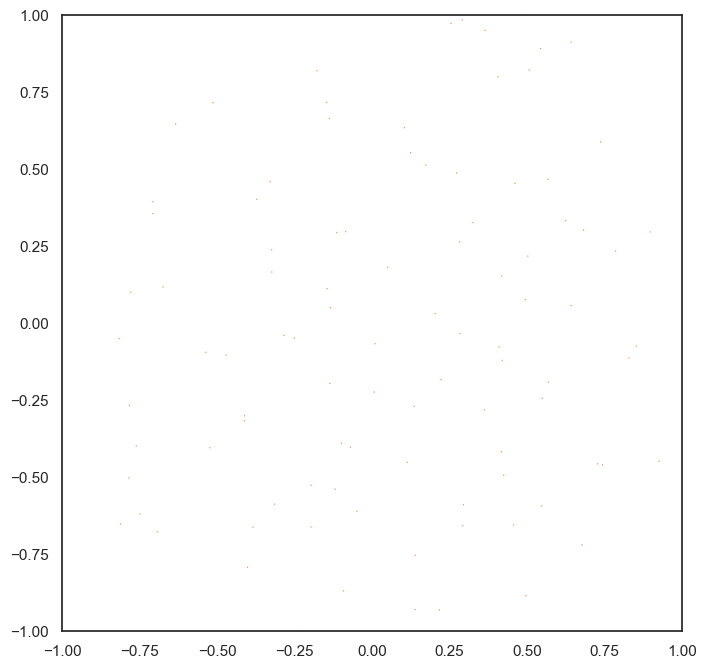

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_umap_100_20251008T143810.png


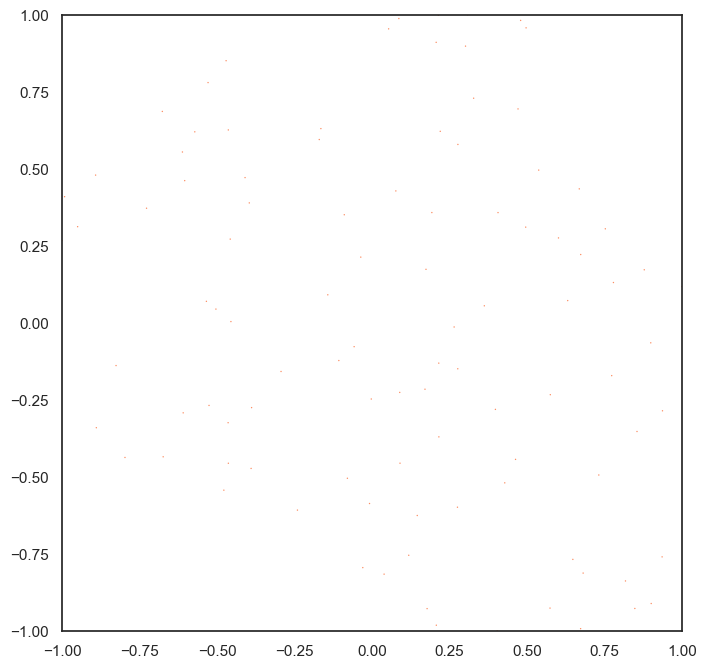

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_tsne_100_20251008T143811.png


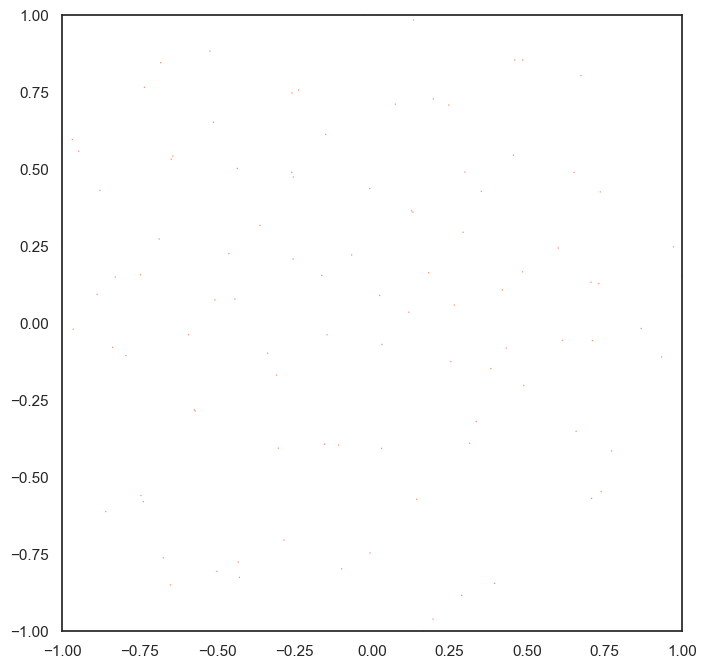

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_umap_100_20251008T143811.png


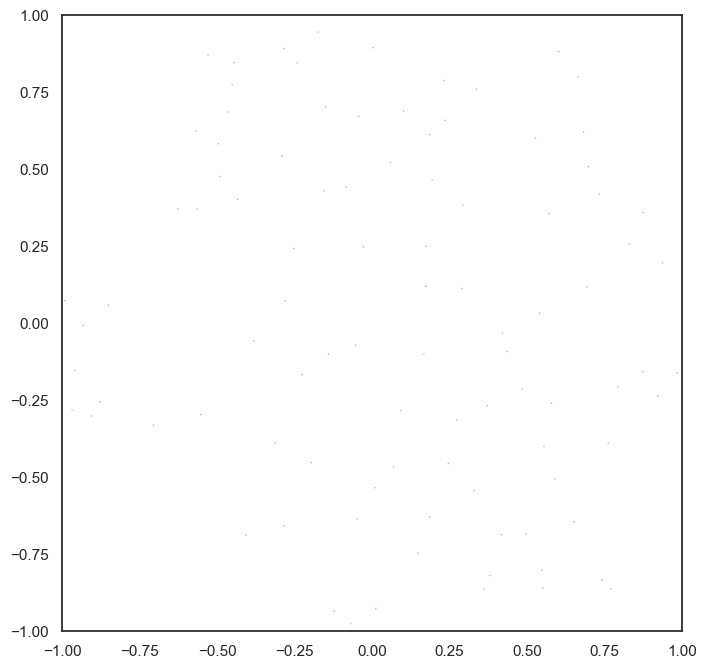

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_tsne_100_20251008T143811.png


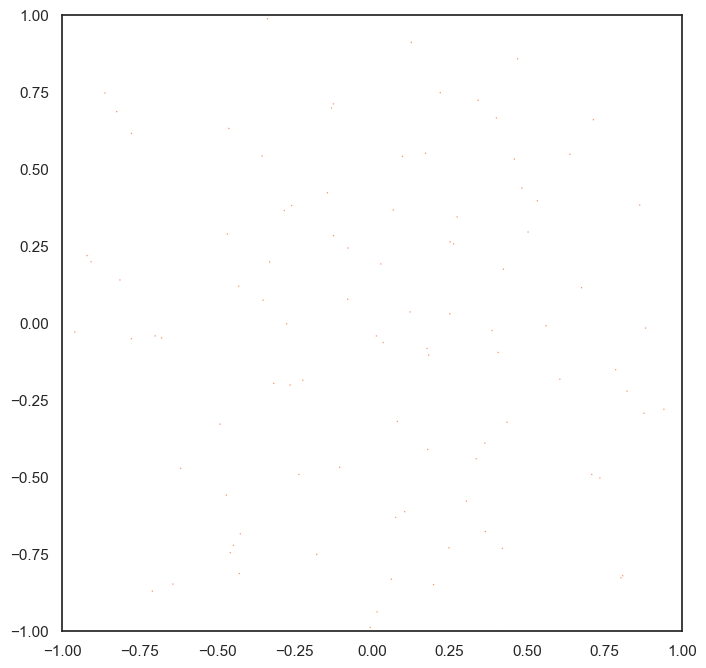

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_umap_100_20251008T143811.png


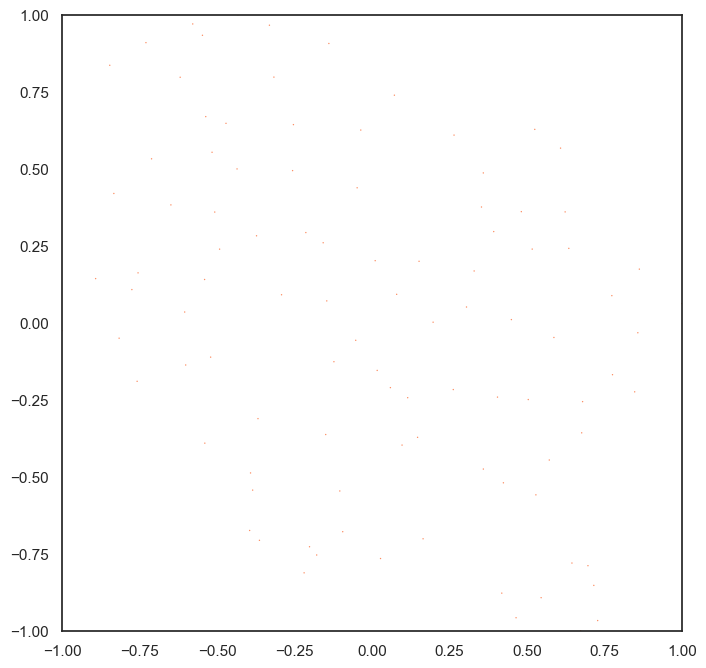

In [13]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

teaser_data = []

for dir in ds_pos_results:
    print("Loading data...")

    ds_pos = load_from_disk(dir)
    teaser_data.append(ds_pos)

    print("Assigning cols...")
    xs = ds_pos["x"]
    ys = ds_pos["y"]

    plt.figure(figsize=(8, 8))  # Square figure size
    sns.set_theme(style="white")

    palette = sns.color_palette("Set2")

    print("Running scatterplot()...")
    # Scatter plot with 1px points
    sns.scatterplot(x=xs, y=ys, s=1, color=palette[1], edgecolor='none')

    # Set fixed square aspect ratio and limits
    plt.xlim(-1.0, 1.0)
    plt.ylim(-1.0, 1.0)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.png"
    filepath = os.path.join(img_dir, filename)

    # Save as PNG
    plt.savefig(filepath, format='png', bbox_inches='tight', dpi=300)
    print(f"Saved plot to: {filepath}")

    plt.show()

Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\teaser_20251008T143813.pdf


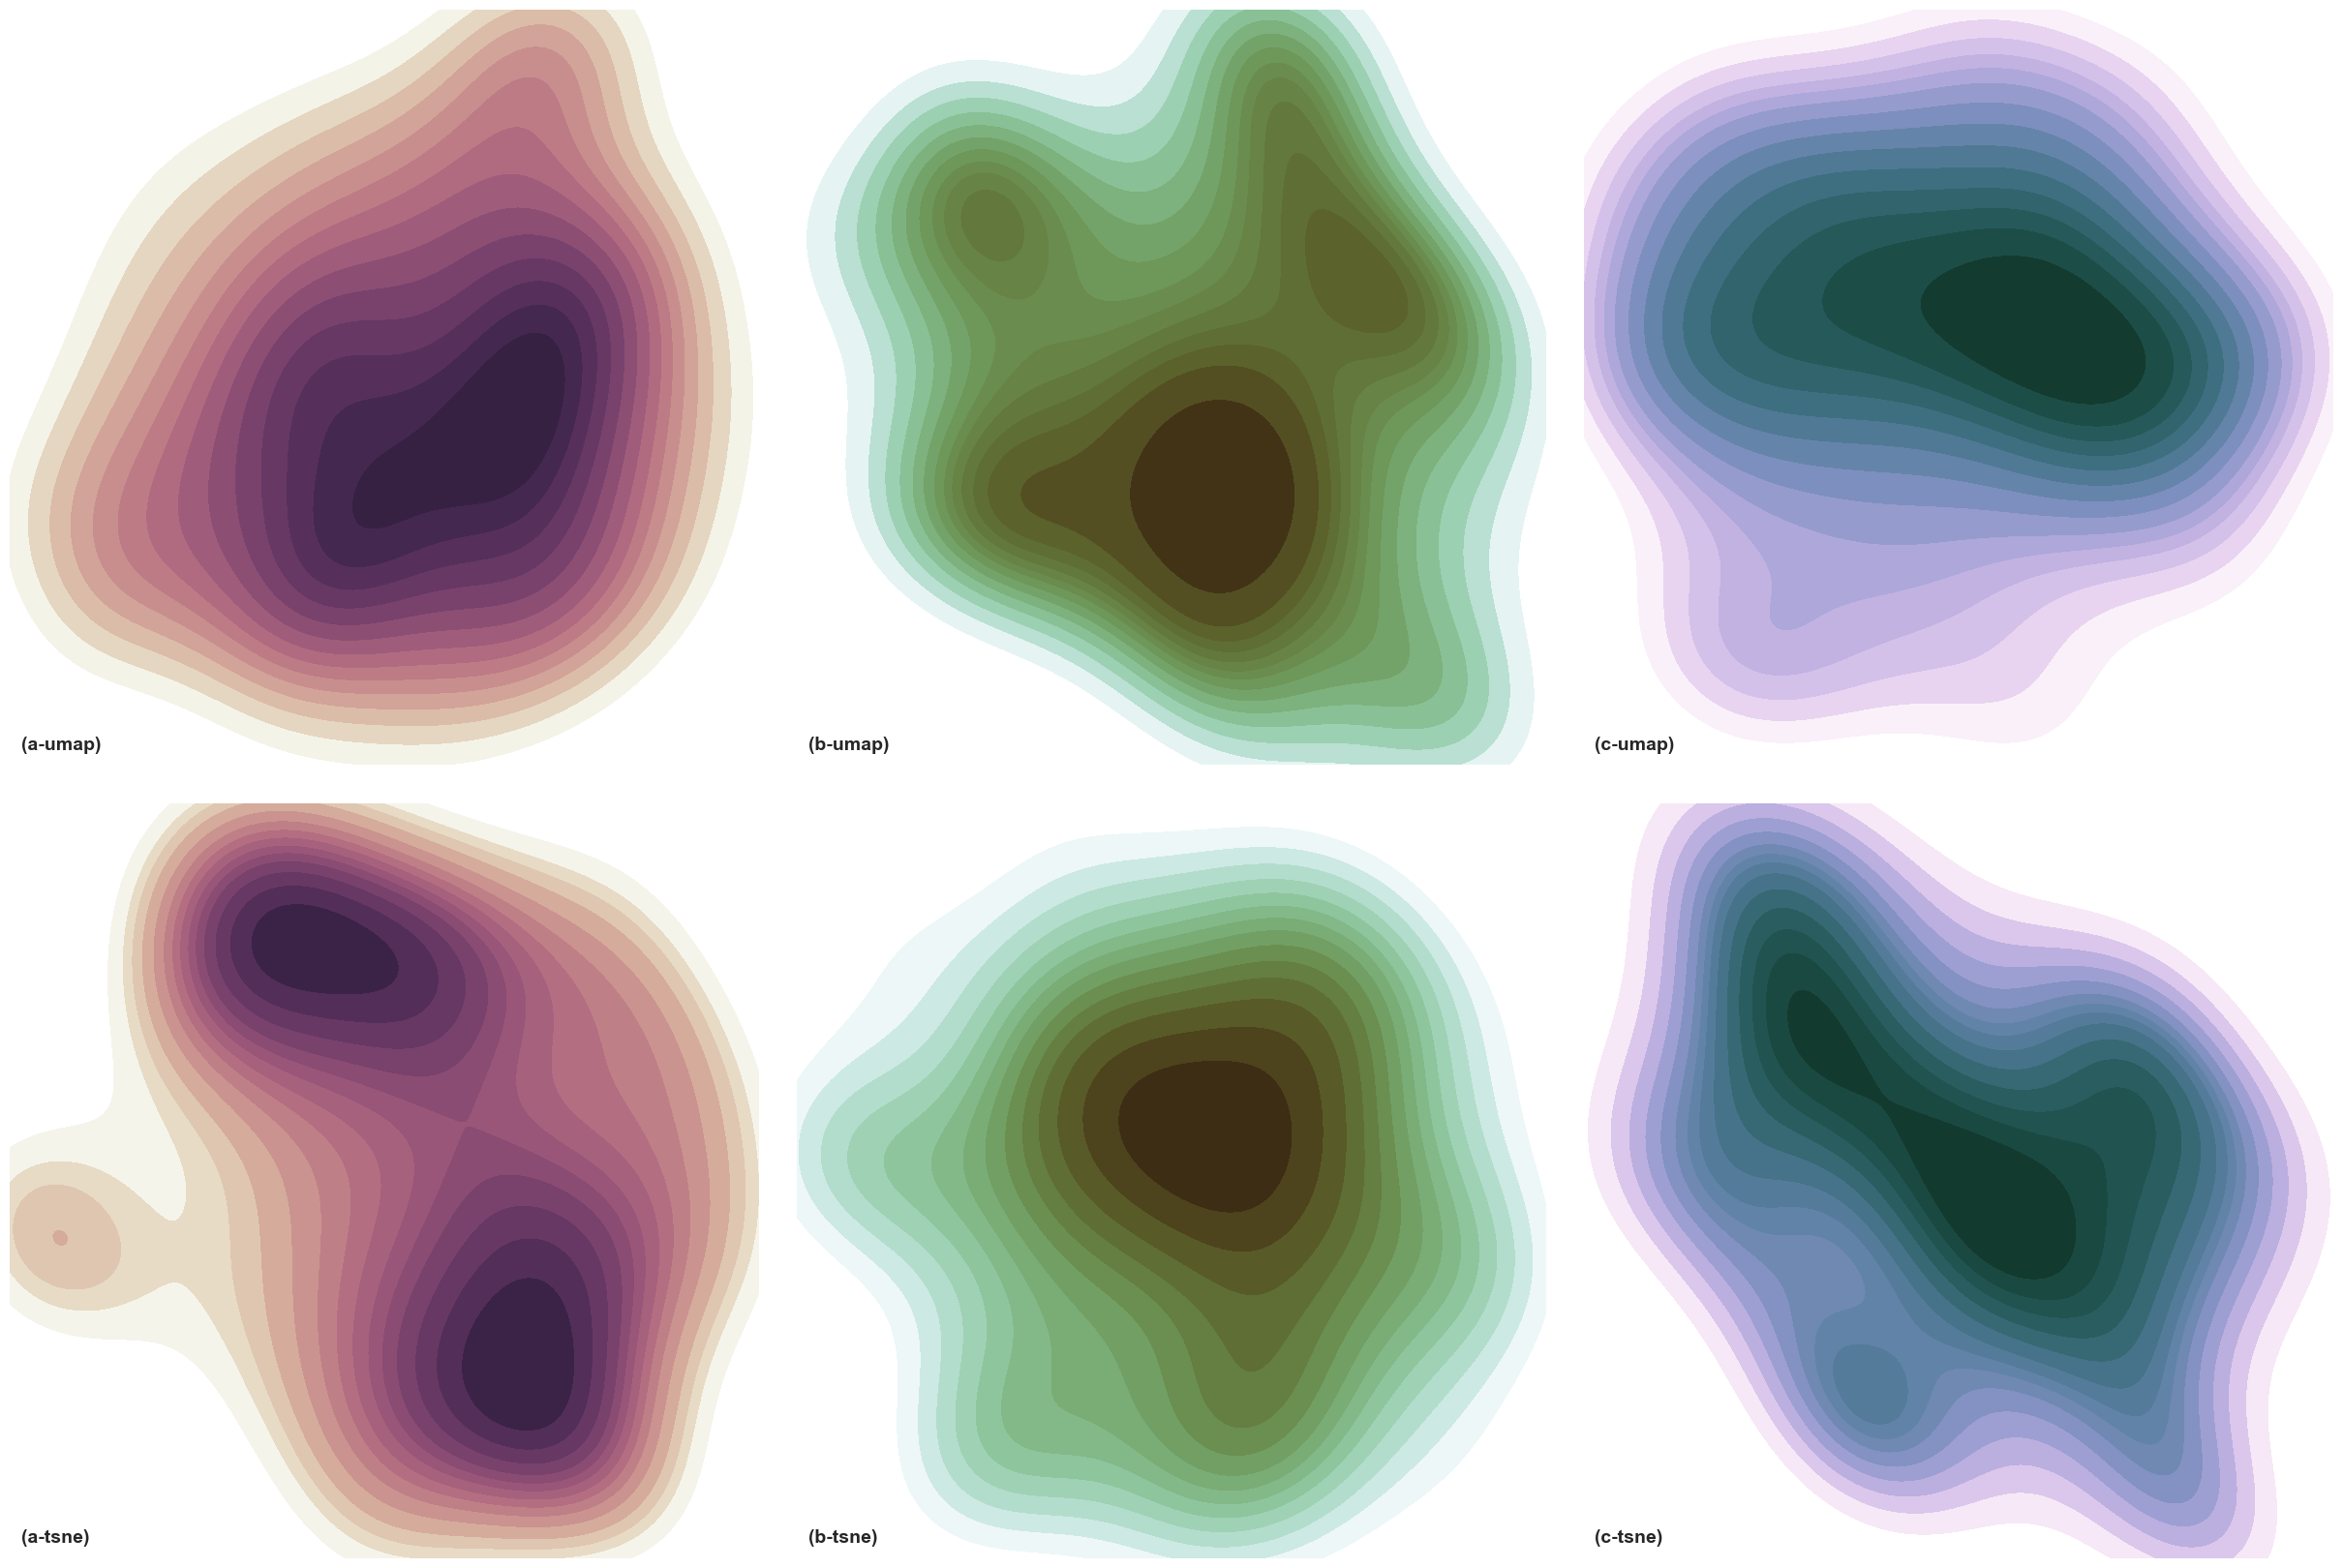

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

sns.set_theme(style="white")

# Labels for 6 subplots
labels = ['(a-umap)', '(b-umap)', '(c-umap)', '(a-tsne)', '(b-tsne)', '(c-tsne)']

# 2 rows, 3 columns
f, axes = plt.subplots(2, 3, figsize=(24, 16), sharex=True, sharey=True)
axes = axes.flatten()

# Use 3 distinct cubehelix starts for the first row and repeat for the second
cubehelix_starts = [0, 1.0, 2.0, 0, 1.0, 2.0]

for ax, ds, label, s in zip(axes, teaser_data, labels, cubehelix_starts):
    x = ds['x']
    y = ds['y']
    
    # Cubehelix colormap
    cmap = sns.cubehelix_palette(start=s, rot=0.5, light=1, as_cmap=True)
    
    # KDE plot
    sns.kdeplot(
        x=x, y=y,
        cmap=cmap,
        fill=True,
        clip=(-1.0, 1.0),
        thresh=0.1,
        levels=15,
        ax=ax,
    )
    
    ax.set_axis_off()
    ax.text(-0.97, -0.96, label, fontsize=14, fontweight='bold')

ax.set(xlim=(-1.0, 1.0), ylim=(-1.0, 1.0))
f.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
filename = f"teaser_{timestamp}.pdf"
filepath = os.path.join(img_dir, filename)

# Save as PDF
plt.savefig(filepath, format='pdf', bbox_inches='tight')
print(f"Saved plot to: {filepath}")

plt.show()